In [ ]:
# preprocessing the data and mapping them


In [2]:
import os
import pandas as pd

# Split both sessions into non-VPN view (inner NFStream side) and VPN view (outer matched side)
IN_DIR = r".\dataset\orginal_F"
OUT_DIR = r".\dataset"
os.makedirs(OUT_DIR, exist_ok=True)

SESSION_FILES = {
    "session1": "session1_flows.csv",
    "session2": "session2_flows.csv",
}

LABEL1 = "application_name"
LABEL2 = "application_category_name"

for sid, fn in SESSION_FILES.items():
    in_file = os.path.join(IN_DIR, fn)
    out_non = os.path.join(OUT_DIR, f"nonvpn_{sid}.csv")
    out_vpn = os.path.join(OUT_DIR, f"vpn_{sid}.csv")

    print(f"\n[{sid}] reading: {in_file}")
    df = pd.read_csv(in_file)

    i1 = df.columns.get_loc(LABEL1)
    i2 = df.columns.get_loc(LABEL2)

    nonvpn_feature_cols = list(df.columns[:i1])
    vpn_feature_cols = list(df.columns[i2 + 1:])

    nonvpn = df[nonvpn_feature_cols].copy()
    vpn = df[vpn_feature_cols].copy()

    for c in [LABEL1, LABEL2]:
        nonvpn[c] = df[c].values
        vpn[c] = df[c].values

    nonvpn["vpn_label"] = 0
    vpn["vpn_label"] = 1

    label_cols = [LABEL1, LABEL2, "vpn_label"]
    nonvpn = nonvpn[[c for c in nonvpn.columns if c not in label_cols] + label_cols]
    vpn = vpn[[c for c in vpn.columns if c not in label_cols] + label_cols]

    nonvpn.to_csv(out_non, index=False)
    vpn.to_csv(out_vpn, index=False)

    print(f"[{sid}] Non-VPN: {nonvpn.shape} -> {out_non}")
    print(f"[{sid}] VPN:     {vpn.shape} -> {out_vpn}")



[session1] reading: .\dataset\orginal_F\session1_flows.csv
[session1] Non-VPN: (122975, 83) -> .\dataset\nonvpn_session1.csv
[session1] VPN:     (122975, 47) -> .\dataset\vpn_session1.csv

[session2] reading: .\dataset\orginal_F\session2_flows.csv
[session2] Non-VPN: (103479, 83) -> .\dataset\nonvpn_session2.csv
[session2] VPN:     (103479, 47) -> .\dataset\vpn_session2.csv


In [3]:
# Filter mapped features for BOTH sessions (includes SPLT columns)
import os
import numpy as np
import pandas as pd

IN_DIR = r".\dataset"
OUT_DIR = r".\dataset\mapped_f"
os.makedirs(OUT_DIR, exist_ok=True)

LABEL_COLS = ["application_name", "application_category_name", "vpn_label"]

SESSIONS = ["session1", "session2"]

VPN_FEATURES = [
    "matched_packets", "outer_bytes", "mean_outer_pkt_size", "std_outer_pkt_size",
    "outer_min_piat_ms", "outer_mean_piat_ms", "outer_stddev_piat_ms", "outer_max_piat_ms",
    "outer_capture_duration_ms", "outer_first_matched_time_ms", "outer_last_matched_time_ms",
    "outer_bytes_in", "outer_bytes_out",
    "outer_min_piat_ms_in", "outer_mean_piat_ms_in", "outer_stddev_piat_ms_in", "outer_max_piat_ms_in",
    "outer_min_piat_ms_out", "outer_mean_piat_ms_out", "outer_stddev_piat_ms_out", "outer_max_piat_ms_out",
    "outer_packet_rate", "outer_byte_rate",
    # new outer SPLT columns
    "outer_splt_direction", "outer_splt_ps", "outer_splt_piat_ms",
]

NONVPN_FEATURES = [
    "bidirectional_packets", "bidirectional_bytes", "bidirectional_mean_ps", "bidirectional_stddev_ps",
    "bidirectional_min_piat_ms", "bidirectional_mean_piat_ms", "bidirectional_stddev_piat_ms", "bidirectional_max_piat_ms",
    "bidirectional_duration_ms", "bidirectional_first_seen_ms", "bidirectional_last_seen_ms",
    "dst2src_bytes", "src2dst_bytes",
    "dst2src_min_piat_ms", "dst2src_mean_piat_ms", "dst2src_stddev_piat_ms", "dst2src_max_piat_ms",
    "src2dst_min_piat_ms", "src2dst_mean_piat_ms", "src2dst_stddev_piat_ms", "src2dst_max_piat_ms",
    "bidirectional_packet_rate", "bidirectional_byte_rate",
    # inner NFStream SPLT columns
    "splt_direction", "splt_ps", "splt_piat_ms",
]


def add_nonvpn_rates(df: pd.DataFrame) -> pd.DataFrame:
    need = {"bidirectional_packets", "bidirectional_bytes", "bidirectional_duration_ms"}
    if not need.issubset(df.columns):
        missing = sorted(list(need - set(df.columns)))
        raise KeyError(f"Missing required columns for rate calc: {missing}")

    dur_s = pd.to_numeric(df["bidirectional_duration_ms"], errors="coerce") / 1000.0
    dur_s = dur_s.replace(0, np.nan)

    packets = pd.to_numeric(df["bidirectional_packets"], errors="coerce")
    bytes_ = pd.to_numeric(df["bidirectional_bytes"], errors="coerce")

    out = df.copy()
    out["bidirectional_packet_rate"] = packets / dur_s
    out["bidirectional_byte_rate"] = bytes_ / dur_s
    return out


def filter_keep_order(df: pd.DataFrame, feature_cols: list[str], label_cols: list[str]) -> pd.DataFrame:
    feats_exist = [c for c in feature_cols if c in df.columns]
    labels_exist = [c for c in label_cols if c in df.columns]
    out = df[feats_exist + labels_exist].copy()
    out = out.reindex(columns=feats_exist + labels_exist)
    return out


for sid in SESSIONS:
    vpn_csv = os.path.join(IN_DIR, f"vpn_{sid}.csv")
    non_csv = os.path.join(IN_DIR, f"nonvpn_{sid}.csv")

    out_vpn = os.path.join(OUT_DIR, f"vpn_{sid}_filtered.csv")
    out_non = os.path.join(OUT_DIR, f"nonvpn_{sid}_filtered.csv")

    vpn_df = pd.read_csv(vpn_csv)
    non_df = pd.read_csv(non_csv)

    non_df = add_nonvpn_rates(non_df)

    vpn_filtered = filter_keep_order(vpn_df, VPN_FEATURES, LABEL_COLS)
    non_filtered = filter_keep_order(non_df, NONVPN_FEATURES, LABEL_COLS)

    print(f"\n[{sid}] VPN original: {vpn_df.shape} -> filtered: {vpn_filtered.shape}")
    print(f"[{sid}] Non-VPN original: {non_df.shape} -> filtered: {non_filtered.shape}")

    missing_vpn = [c for c in VPN_FEATURES if c not in vpn_df.columns]
    missing_non = [c for c in NONVPN_FEATURES if c not in non_df.columns]
    print(f"[{sid}] Missing VPN features: {missing_vpn}")
    print(f"[{sid}] Missing Non-VPN features: {missing_non}")

    vpn_filtered.to_csv(out_vpn, index=False)
    non_filtered.to_csv(out_non, index=False)

    print(f"[{sid}] Saved: {out_vpn} and {out_non}")



[session1] VPN original: (122975, 47) -> filtered: (122975, 29)
[session1] Non-VPN original: (122975, 85) -> filtered: (122975, 29)
[session1] Missing VPN features: []
[session1] Missing Non-VPN features: []
[session1] Saved: .\dataset\mapped_f\vpn_session1_filtered.csv and .\dataset\mapped_f\nonvpn_session1_filtered.csv

[session2] VPN original: (103479, 47) -> filtered: (103479, 29)
[session2] Non-VPN original: (103479, 85) -> filtered: (103479, 29)
[session2] Missing VPN features: []
[session2] Missing Non-VPN features: []
[session2] Saved: .\dataset\mapped_f\vpn_session2_filtered.csv and .\dataset\mapped_f\nonvpn_session2_filtered.csv


In [ ]:
# show the statistic of the data 

Non-VPN Application Category Counts
application_category_name
Web               110690
Network            84448
Collaborative       6632
Cloud               5778
Unspecified         5680
Chat                3985
SocialNetwork       3883
VoIP                1601
System              1230
SoftwareUpdate       737
Download             651
Email                391
Database             327
ConnCheck            281
VPN                   84
Media                 24
DataTransfer          19
Advertisement         10
Video                  2
Game                   1
Name: count, dtype: int64

VPN Application Category Counts
application_category_name
Web               110690
Network            84448
Collaborative       6632
Cloud               5778
Unspecified         5680
Chat                3985
SocialNetwork       3883
VoIP                1601
System              1230
SoftwareUpdate       737
Download             651
Email                391
Database             327
ConnCheck            281
VPN

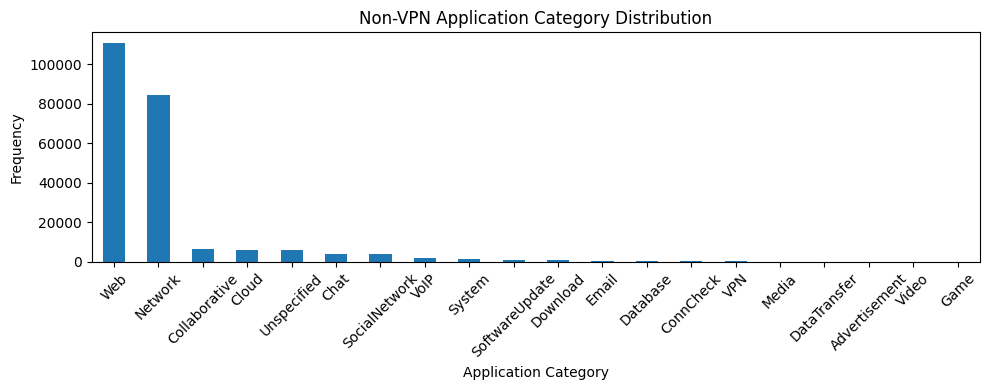

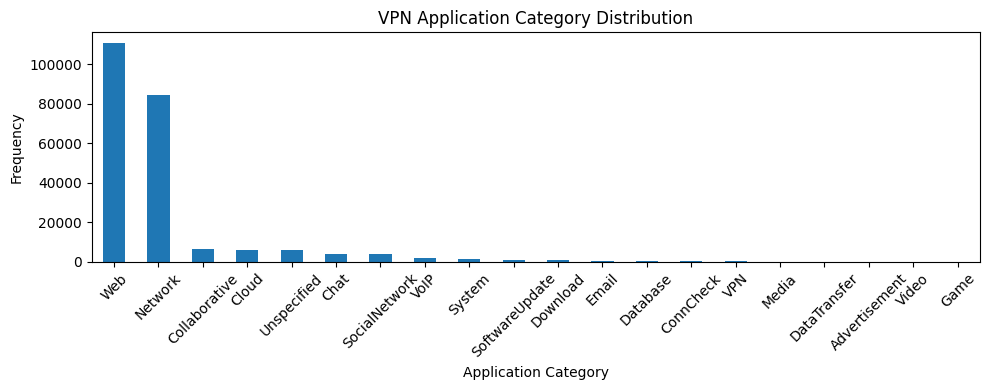


Combined shapes:
nonvpn_all: (226454, 29)
vpn_all: (226454, 29)


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load both sessions after mapped filtering
nonvpn_s1 = pd.read_csv(r".\dataset\mapped_f\nonvpn_session1_filtered.csv")
nonvpn_s2 = pd.read_csv(r".\dataset\mapped_f\nonvpn_session2_filtered.csv")
vpn_s1 = pd.read_csv(r".\dataset\mapped_f\vpn_session1_filtered.csv")
vpn_s2 = pd.read_csv(r".\dataset\mapped_f\vpn_session2_filtered.csv")

nonvpn_all = pd.concat([nonvpn_s1, nonvpn_s2], ignore_index=True)
vpn_all = pd.concat([vpn_s1, vpn_s2], ignore_index=True)

nonvpn_counts = nonvpn_all["application_category_name"].value_counts().sort_values(ascending=False)
vpn_counts = vpn_all["application_category_name"].value_counts().sort_values(ascending=False)

print("Non-VPN Application Category Counts")
print(nonvpn_counts)
print("\nVPN Application Category Counts")
print(vpn_counts)

plt.figure(figsize=(10, 4))
nonvpn_counts.plot(kind="bar")
plt.title("Non-VPN Application Category Distribution")
plt.xlabel("Application Category")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
vpn_counts.plot(kind="bar")
plt.title("VPN Application Category Distribution")
plt.xlabel("Application Category")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nCombined shapes:")
print("nonvpn_all:", nonvpn_all.shape)
print("vpn_all:", vpn_all.shape)


In [5]:
# Drop classes with fewer than THRESH samples from BOTH sides using one consistent rule
THRESH = 200

all_data = pd.concat([nonvpn_all, vpn_all], ignore_index=True)
class_counts = all_data["application_category_name"].value_counts()
keep_classes = class_counts[class_counts >= THRESH].index

nonvpn_all_clean = nonvpn_all[nonvpn_all["application_category_name"].isin(keep_classes)].reset_index(drop=True)
vpn_all_clean = vpn_all[vpn_all["application_category_name"].isin(keep_classes)].reset_index(drop=True)

print("Kept classes:", len(keep_classes))
print("Dropped classes:", int((class_counts < THRESH).sum()))
print("Non-VPN before:", nonvpn_all.shape, "after:", nonvpn_all_clean.shape)
print("VPN before:", vpn_all.shape, "after:", vpn_all_clean.shape)

nonvpn_all_clean.to_csv(r".\dataset\mapped_f\nonvpn_all_filtered_min200.csv", index=False)
vpn_all_clean.to_csv(r".\dataset\mapped_f\vpn_all_filtered_min200.csv", index=False)

print("Saved: nonvpn_all_filtered_min200.csv, vpn_all_filtered_min200.csv")


Kept classes: 14
Dropped classes: 6
Non-VPN before: (226454, 29) after: (226314, 29)
VPN before: (226454, 29) after: (226314, 29)
Saved: nonvpn_all_filtered_min200.csv, vpn_all_filtered_min200.csv
